In [11]:
# === Imports & setup ===
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.sparse as sp

# NLP utils
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize

# SKLearn / TF
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# SHAP
# If not installed, uncomment the next line, run once, then re-run the notebook.
# !pip install shap
import shap

# NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [12]:
# === Load models / artifacts from project folder ===
NB_PATH = "naive_bayes_model.pkl"
VEC_PATH = "vectorizer.pkl"
TOK_PATH = "tokenizer.pkl"
LSTM_PATH = "lstm_model.h5"

with open(NB_PATH, "rb") as f:
    nb_model = pickle.load(f)
with open(VEC_PATH, "rb") as f:
    vectorizer = pickle.load(f)
with open(TOK_PATH, "rb") as f:
    tokenizer = pickle.load(f)

lstm_model = load_model(LSTM_PATH)

print("✓ Artifacts loaded")
print("  NB expects features:", getattr(nb_model, "n_features_in_", "unknown"))
print("  Vectorizer features:", len(vectorizer.get_feature_names_out()))



✓ Artifacts loaded
  NB expects features: 5005
  Vectorizer features: 5000


In [13]:
# === Utilities ===
def _ensure_feature_dim(X, expected):
    """Pad (zeros) or truncate columns to ensure X has 'expected' number of features."""
    if sp.issparse(X):
        n = X.shape[1]
        if n == expected:
            return X
        if n < expected:
            pad = sp.csr_matrix((X.shape[0], expected - n))
            return sp.hstack([X, pad], format="csr")
        return X[:, :expected]
    else:
        n = X.shape[1]
        if n == expected:
            return X
        if n < expected:
            pad = np.zeros((X.shape[0], expected - n), dtype=X.dtype)
            return np.hstack([X, pad])
        return X[:, :expected]



In [14]:
# === Load dataset into df ===
DATA_LOCAL = "data/fake_job_postings.csv"

if os.path.exists(DATA_LOCAL):
    df = pd.read_csv(DATA_LOCAL)
    print(f"✓ Loaded local file: {DATA_LOCAL} ({df.shape[0]} rows)")
else:
    # Fallback to KaggleHub
    try:
        import kagglehub, shutil
        path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
        src = os.path.join(path, "fake_job_postings.csv")
        os.makedirs("data", exist_ok=True)
        shutil.copy2(src, DATA_LOCAL)
        df = pd.read_csv(DATA_LOCAL)
        print(f"✓ Downloaded via KaggleHub and saved to: {DATA_LOCAL} ({df.shape[0]} rows)")
    except Exception as e:
        raise RuntimeError("Could not load dataset. Place fake_job_postings.csv at data/ and re-run.") from e

# Build combined text field
def combine_text_fields(row):
    cols = [
        "title","company_profile","description","requirements","benefits",
        "telecommuting","has_company_logo","has_questions",
        "employment_type","required_experience","required_education",
        "industry","function","location","department","salary_range"
    ]
    cols = [c for c in cols if c in row.index]
    parts = []
    for c in cols:
        v = row[c]
        if pd.isna(v):
            continue
        parts.append(str(v))
    text = " ".join(parts)
    return " ".join(text.split())

if "text_all" not in df.columns:
    df["text_all"] = df.apply(combine_text_fields, axis=1)

print("✓ text_all built")


✓ Loaded local file: data/fake_job_postings.csv (17880 rows)
✓ text_all built


In [15]:
def safe_display_field(val, max_length=180):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return ""
    s = " ".join(str(val).split())
    return s if len(s) <= max_length else (s[:max_length] + "...")


In [16]:
class InterpretableEnsemble:
    """
    Wraps Naive Bayes + LSTM ensemble with multi-layer attribution methods.
    Handles both TF-IDF text features AND numeric features.
    """

    def __init__(self, nb_model, lstm_model, vectorizer, tokenizer, training_df=None):
        self.nb = nb_model
        self.lstm = lstm_model
        self.vectorizer = vectorizer
        self.tokenizer = tokenizer
        self.training_df = training_df

        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

        print("✓ InterpretableEnsemble initialized")

    def predict_with_explanation(self, text,
                                 telecommuting=0,
                                 has_company_logo=0,
                                 has_questions=0,
                                 ensemble_strategy='rule_boosted'):  # NEW parameter
        """
        Comprehensive prediction with explanations.

        Args:
            text (str): Job posting text
            telecommuting (int): 0 or 1
            has_company_logo (int): 0 or 1
            has_questions (int): 0 or 1
            ensemble_strategy (str): 'simple', 'weighted', or 'rule_boosted' (default)

        Returns:
            dict: Fraud probability, decision, and multi-level explanations
        """

        # ===== PREPROCESS TEXT =====
        text_processed = self._preprocess_text(text)

        # ===== CALCULATE NUMERIC FEATURES =====
        location_fraud_ratio = 0.05
        character_count = len(text)

        # ===== GET NB PREDICTIONS =====
        nb_text_features = self.vectorizer.transform([text_processed])

        numeric_features = np.array([
            telecommuting,
            has_company_logo,
            has_questions,
            location_fraud_ratio,
            character_count
        ]).reshape(1, -1)

        from scipy.sparse import csr_matrix, hstack
        numeric_features_sparse = csr_matrix(numeric_features)
        nb_combined_features = hstack([nb_text_features, numeric_features_sparse])

        nb_prob = self.nb.predict_proba(nb_combined_features)[0, 1]

        # ===== GET LSTM PREDICTIONS =====
        from tensorflow.keras.preprocessing.sequence import pad_sequences
        lstm_sequence = self.tokenizer.texts_to_sequences([text_processed])
        lstm_padded = pad_sequences(lstm_sequence, maxlen=200)
        lstm_prob = float(self.lstm.predict(lstm_padded, verbose=0)[0, 0])

        # ===== DETECT PATTERNS (needed for rule-boosting) =====
        patterns = self._detect_patterns(text)

        # ===== APPLY ENSEMBLE STRATEGY =====
        numeric_features_dict = {
            'telecommuting': telecommuting,
            'has_company_logo': has_company_logo,
            'has_questions': has_questions,
            'location_fraud_ratio': location_fraud_ratio,
            'character_count': character_count
        }

        if ensemble_strategy == 'simple':
            # Original: Simple average
            fraud_prob = (nb_prob + lstm_prob) / 2.0
            strategy_info = "Simple averaging (50/50)"
            boost_details = []

        elif ensemble_strategy == 'weighted':
            # Strategy 1: Fixed weights (LSTM=65%, NB=35%)
            fraud_prob = 0.35 * nb_prob + 0.65 * lstm_prob
            strategy_info = "Weighted averaging (NB=35%, LSTM=65%)"
            boost_details = []

        elif ensemble_strategy == 'rule_boosted':
            # Strategy 2: Rule-based boosting (RECOMMENDED)
            fraud_prob, strategy_info, boost_details = self._rule_boosted_ensemble(
                nb_prob, lstm_prob, numeric_features_dict, patterns, text
            )

        # ===== RISK CLASSIFICATION =====
        risk_level, risk_icon, recommendation = self._get_risk_classification(fraud_prob)

        # ===== GENERATE EXPLANATIONS =====
        explanation = self._generate_explanation(
            text=text,
            text_processed=text_processed,
            nb_features=nb_text_features,
            fraud_prob=fraud_prob,
            numeric_features=numeric_features_dict
        )

        # ===== RETURN ENHANCED RESULTS =====
        return {
            'fraud_probability': fraud_prob,
            'fraud_probability_pct': f"{fraud_prob*100:.1f}%",
            'risk_level': risk_level,           # NEW
            'risk_icon': risk_icon,             # NEW
            'recommendation': recommendation,    # NEW
            'ensemble_decision': 'FRAUD' if fraud_prob > 0.5 else 'REAL',
            'ensemble_strategy': strategy_info, # NEW
            'boost_details': boost_details,     # NEW
            'confidence': self._calculate_confidence(nb_prob, lstm_prob, fraud_prob),  # UPDATED
            'individual_predictions': {
                'naive_bayes_score': f"{nb_prob:.4f}",
                'lstm_score': f"{lstm_prob:.4f}",
                'agreement': abs(nb_prob - lstm_prob) < 0.15,
                'disagreement_margin': f"{abs(nb_prob - lstm_prob):.4f}"
            },
            'explanation': explanation,
            'features_used': numeric_features_dict
        }

    def _preprocess_text(self, text):
        """Preprocess text matching training pipeline"""
        tokens = word_tokenize(str(text).lower())
        tokens = [token for token in tokens
                 if token.isalpha() and token not in self.stop_words]
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
        return ' '.join(tokens)

    def _generate_explanation(self, text, text_processed, nb_features, fraud_prob, numeric_features):
        """Multi-level explanation generation"""
        return {
            'top_fraud_indicators': self._extract_top_features(nb_features),
            'sentence_attributions': self._highlight_risky_sentences(
                text, text_processed, nb_features
            ),
            'linguistic_flags': self._detect_patterns(text),
            'numeric_features_impact': self._explain_numeric_features(numeric_features),
            'confidence_reasoning': self._explain_confidence(fraud_prob)
        }

    def _extract_top_features(self, nb_features, top_n=10):
        """Extract top TF-IDF features driving fraud prediction"""
        feature_names = np.array(self.vectorizer.get_feature_names_out())
        feature_log_prob_fraud = self.nb.feature_log_prob_[1][:5000]  # Only TF-IDF features
        feature_log_prob_real = self.nb.feature_log_prob_[0][:5000]

        tfidf_scores = nb_features.toarray()[0]
        fraud_weight = feature_log_prob_fraud - feature_log_prob_real
        contribution = tfidf_scores * fraud_weight

        top_indices = np.argsort(contribution)[-top_n:][::-1]

        top_features = {}
        for idx in top_indices:
            if contribution[idx] > 0:
                feature = feature_names[idx]
                top_features[feature] = {
                    'fraud_weight': float(fraud_weight[idx]),
                    'tfidf_score': float(tfidf_scores[idx]),
                    'contribution': float(contribution[idx])
                }

        return top_features

    def _highlight_risky_sentences(self, text, text_processed, nb_features, top_n=5):
        """Sentence-level attribution"""
        sentences = sent_tokenize(text)
        sentence_scores = []

        feature_names = np.array(self.vectorizer.get_feature_names_out())
        feature_log_prob_fraud = self.nb.feature_log_prob_[1][:5000]
        feature_log_prob_real = self.nb.feature_log_prob_[0][:5000]
        fraud_weights = feature_log_prob_fraud - feature_log_prob_real

        for sentence in sentences:
            sent_processed = self._preprocess_text(sentence)
            sent_features = self.vectorizer.transform([sent_processed])

            tfidf_scores = sent_features.toarray()[0]
            sent_fraud_score = np.sum(tfidf_scores * fraud_weights)
            sent_fraud_score = sent_fraud_score / (len(sent_processed.split()) + 1)

            patterns = self._detect_patterns_in_sentence(sentence)
            pattern_risk = len(patterns) * 0.15

            total_risk = max(0, min(1, sent_fraud_score + pattern_risk))

            sentence_scores.append({
                'sentence': sentence.strip(),
                'fraud_risk': total_risk,
                'fraud_risk_pct': f"{total_risk*100:.0f}%",
                'contributing_features': self._get_sentence_features(sent_features),
                'flagged_patterns': patterns
            })

        sentence_scores.sort(key=lambda x: x['fraud_risk'], reverse=True)
        return sentence_scores[:top_n]

    def _get_sentence_features(self, sent_features, top_n=3):
        """Extract top TF-IDF features from sentence"""
        feature_names = np.array(self.vectorizer.get_feature_names_out())
        tfidf_scores = sent_features.toarray()[0]

        top_indices = np.argsort(tfidf_scores)[-top_n:][::-1]

        features = {}
        for idx in top_indices:
            if tfidf_scores[idx] > 0:
                features[feature_names[idx]] = float(tfidf_scores[idx])

        return features

    def _detect_patterns_in_sentence(self, sentence):
        """Detect linguistic red flags in sentence"""
        patterns = []
        sent_lower = sentence.lower()

        urgency_keywords = ['urgent', 'immediately', 'asap', 'deadline', 'quick', 'hurry']
        if any(keyword in sent_lower for keyword in urgency_keywords):
            patterns.append('Urgency indicator')

        payment_keywords = ['payment', 'fee', 'upfront', 'investment', 'wire', 'bitcoin']
        if any(keyword in sent_lower for keyword in payment_keywords):
            patterns.append('Payment request')

        vague_keywords = ['flexible', 'negotiable', 'not specified', 'tbd']
        if any(keyword in sent_lower for keyword in vague_keywords):
            patterns.append('Vague language')

        if '  ' in sentence or '..' in sentence or '!!' in sentence:
            patterns.append('Grammar issues')

        return patterns

    def _detect_patterns(self, text):
        """High-level pattern detection"""
        text_lower = text.lower()
        text_len = len(text)
        avg_sentence_len = np.mean([len(s.split()) for s in sent_tokenize(text)])

        return {
            'urgency_indicators': {
                'present': any(kw in text_lower for kw in ['urgent', 'asap', 'immediately']),
                'examples': [kw for kw in ['urgent', 'asap', 'immediately'] if kw in text_lower]
            },
            'payment_requests': {
                'present': any(kw in text_lower for kw in ['payment', 'fee', 'upfront']),
                'examples': [kw for kw in ['payment', 'fee', 'upfront'] if kw in text_lower]
            },
            'vague_language': {
                'present': any(kw in text_lower for kw in ['flexible', 'tbd', 'negotiable']),
                'examples': [kw for kw in ['flexible', 'tbd', 'negotiable'] if kw in text_lower]
            },
            'text_quality': {
                'word_count': len(text.split()),
                'character_count': text_len,
                'avg_sentence_length': round(avg_sentence_len, 2)
            }
        }

    def _explain_numeric_features(self, numeric_features):
        """Explain the impact of numeric features"""
        explanations = []

        if numeric_features['telecommuting'] == 1:
            explanations.append("✅ Job offers telecommuting (slightly lower fraud risk)")
        else:
            explanations.append("⚠️ No telecommuting mentioned")

        if numeric_features['has_company_logo'] == 1:
            explanations.append("✅ Job posting has company logo (lower fraud risk)")
        else:
            explanations.append("🚨 No company logo (common in fraud postings)")

        if numeric_features['has_questions'] == 1:
            explanations.append("✅ Job has screening questions (lower fraud risk)")
        else:
            explanations.append("⚠️ No screening questions")

        if numeric_features['character_count'] < 500:
            explanations.append("🚨 Very short job description (red flag)")
        elif numeric_features['character_count'] > 5000:
            explanations.append("⚠️ Unusually long description")
        else:
            explanations.append("✅ Normal description length")

        return {
            'features': numeric_features,
            'interpretations': explanations
        }

    def _explain_confidence(self, fraud_prob):
        """Provide reasoning for confidence level"""
        if fraud_prob > 0.8:
            confidence = 'VERY HIGH'
            reasoning = 'Strong fraud indicators detected'
            recommendation = 'DO NOT APPLY - High fraud risk'
        elif fraud_prob > 0.6:
            confidence = 'HIGH'
            reasoning = 'Multiple fraud indicators present'
            recommendation = 'PROCEED WITH CAUTION'
        elif fraud_prob > 0.4:
            confidence = 'MODERATE'
            reasoning = 'Mixed signals detected'
            recommendation = 'VERIFY company information'
        elif fraud_prob > 0.2:
            confidence = 'LOW'
            reasoning = 'Mostly safe indicators'
            recommendation = 'LIKELY SAFE'
        else:
            confidence = 'VERY LOW'
            reasoning = 'Strong legitimate indicators'
            recommendation = 'SAFE'

        return {
            'confidence_level': confidence,
            'fraud_probability': fraud_prob,
            'reasoning': reasoning,
            'recommendation': recommendation
        }

    def _rule_boosted_ensemble(self, nb_prob, lstm_prob, numeric_features, patterns, text):
        """
        Rule-based ensemble boosting with fraud heuristics.

        Adds fraud probability based on red flags:
        - Missing company features
        - Linguistic patterns (urgency, payment, vague language)
        - Grammar issues
        - Model disagreement indicators

        Returns:
            tuple: (fraud_prob, strategy_description, boost_details_list)
        """

        # Start with weighted average (favor LSTM slightly)
        base_prob = 0.25 * nb_prob + 0.75 * lstm_prob

        # Initialize boost tracking
        boost = 0.0
        boost_details = []

        # ===== RED FLAG CHECKS =====

        # Red Flag 1: Missing company logo (5% boost)
        if numeric_features['has_company_logo'] == 0:
            boost += 0.05
            boost_details.append("🚩 No company logo (+5%)")

        # Red Flag 2: No screening questions (5% boost)
        if numeric_features['has_questions'] == 0:
            boost += 0.05
            boost_details.append("🚩 No screening questions (+5%)")

        # Red Flag 3: Urgency indicators (8% boost)
        if patterns['urgency_indicators']['present']:
            keywords = ', '.join(patterns['urgency_indicators']['examples'][:3])
            boost += 0.08
            boost_details.append(f"🚩 Urgency language: {keywords} (+8%)")

        # Red Flag 4: Payment requests (12% boost - STRONG signal!)
        if patterns['payment_requests']['present']:
            keywords = ', '.join(patterns['payment_requests']['examples'][:3])
            boost += 0.12
            boost_details.append(f"🚩 Payment mentions: {keywords} (+12%)")

        # Red Flag 5: Vague language (4% boost)
        if patterns['vague_language']['present']:
            keywords = ', '.join(patterns['vague_language']['examples'][:2])
            boost += 0.04
            boost_details.append(f"🚩 Vague terms: {keywords} (+4%)")

        # Red Flag 6: Very short text (6% boost)
        if numeric_features['character_count'] < 300:
            boost += 0.06
            boost_details.append(f"🚩 Very short description ({numeric_features['character_count']} chars) (+6%)")

        # Red Flag 7: Grammar issues (5% boost)
        # Assuming _count_grammar_issues exists or will be added
        # For now, let's just make it a placeholder if it's not crucial to this fix
        # if self._count_grammar_issues(text) > 3:
        #    boost += 0.05
        #    boost_details.append(f"🚩 Grammar issues (+5%)")

        # Red Flag 8: Model disagreement with LSTM suspicious (10% boost)
        # This catches subtle frauds where LSTM sees patterns but NB doesn't
        if lstm_prob > 0.35 and nb_prob < 0.05:
            boost += 0.10
            boost_details.append(f"🚩 LSTM pattern detection (LSTM={lstm_prob:.1%}, NB={nb_prob:.1%}) (+10%)")

        # Apply boost (cap at 0.95 to avoid overconfidence)
        fraud_prob = min(base_prob + boost, 0.95)

        # Create strategy description
        if boost > 0:
            strategy_desc = f"Rule-boosted ensemble (base: {base_prob:.1%} + boost: {boost:.1%} = {fraud_prob:.1%})"
        else:
            strategy_desc = f"Weighted ensemble (no red flags detected)"

        return fraud_prob, strategy_desc, boost_details

    def _get_risk_classification(self, fraud_prob):
        """
        Three-tier risk classification system.

        Args:
            fraud_prob (float): Ensemble fraud probability (0-1)

        Returns:
            tuple: (risk_level, risk_icon, recommendation)
        """

        if fraud_prob > 0.60:
            return (
                'HIGH RISK',
                '🔴',
                'DO NOT APPLY - Strong fraud indicators detected'
            )
        elif fraud_prob > 0.20:
            return (
                'MEDIUM RISK',
                '🟡',
                'INVESTIGATE CAREFULLY - Verify company details, check reviews, research employer'
            )
        else:
            return (
                'LOW RISK',
                '🟢',
                'APPEARS SAFE - Standard application precautions recommended'
            )

    def _calculate_confidence(self, nb_prob, lstm_prob, fraud_prob):
        """
        Calculate confidence level based on model agreement and probability extremes.

        Args:
            nb_prob (float): Naive Bayes probability
            lstm_prob (float): LSTM probability
            fraud_prob (float): Final ensemble probability

        Returns:
            str: 'HIGH', 'MEDIUM', or 'LOW'
        """

        disagreement = abs(nb_prob - lstm_prob)

        # High confidence conditions:
        # 1. Models strongly agree (disagreement < 15%)
        # 2. Extreme probability (>80% or <10%)
        if disagreement < 0.15:
            return 'HIGH'
        elif fraud_prob > 0.80 or fraud_prob < 0.10:
            return 'HIGH'
        elif disagreement < 0.30:
            return 'MEDIUM'
        else:
            return 'LOW'

    # Helper method for rule_boosted_ensemble, assuming it exists or needs to be added.
    # Adding a dummy implementation if not present to avoid NameError for now.
    def _count_grammar_issues(self, text):
        # This is a placeholder. Implement actual grammar check logic if needed.
        # For simplicity, returning a fixed value or basic check for now.
        issues = 0
        if '  ' in text: issues += 1
        if '..' in text: issues += 1
        if '!!' in text: issues += 1
        return issues

print("✓ Updated InterpretableEnsemble class defined")

✓ Updated InterpretableEnsemble class defined


In [17]:
ensemble = InterpretableEnsemble(
    nb_model=nb_model,
    lstm_model=lstm_model,
    vectorizer=vectorizer,
    tokenizer=tokenizer
)
print("✓ InterpretableEnsemble initialized")

✓ InterpretableEnsemble initialized
✓ InterpretableEnsemble initialized


In [18]:
# === SHAP helpers (background, NB explainer, LSTM explainer) ===

# 1) Build background text (small sample for speed)
BACKGROUND_N = 50
background_text = df["text_all"].dropna().sample(min(BACKGROUND_N, len(df)), random_state=7).tolist()

# 2) NB (TF-IDF) background matrix and dimension normalization
X_bg_sparse = vectorizer.transform(background_text)
EXPECTED = getattr(nb_model, "n_features_in_", X_bg_sparse.shape[1])
X_bg_sparse = _ensure_feature_dim(X_bg_sparse, EXPECTED)
X_bg_dense  = X_bg_sparse[:50].toarray()  # KernelExplainer prefers dense background

# 3) NB predict wrapper returning positive class probability
def nb_predict_proba_pos(X_dense):
    X_csr = sp.csr_matrix(X_dense)
    exp = getattr(nb_model, "n_features_in_", X_csr.shape[1])
    X_csr = _ensure_feature_dim(X_csr, exp)
    return nb_model.predict_proba(X_csr)[:, 1]

# 4) NB SHAP explainer (Kernel)
nb_explainer = shap.KernelExplainer(
    nb_predict_proba_pos,
    X_bg_dense
)

# 5) LSTM SHAP: Text masker + wrapper that returns probs
# Infer MAXLEN from model input
# --- LSTM SHAP: Text masker + wrapper that returns ONLY fraud prob (1D) ---
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    _shape = getattr(lstm_model, "input_shape", None)
    MAXLEN = _shape[1] if (isinstance(_shape, (list, tuple)) and len(_shape) > 1 and _shape[1]) else 200
except Exception:
    MAXLEN = 200

def lstm_predict_proba_pos(raw_texts):
    # returns 1D: P(fraud) for each text
    seqs = tokenizer.texts_to_sequences(raw_texts)
    X = pad_sequences(seqs, maxlen=MAXLEN, padding="post", truncating="post")
    preds = lstm_model.predict(X, verbose=0).flatten()
    return preds  # 1D array (n,)

text_masker = shap.maskers.Text(tokenizer=None)

lstm_explainer = shap.Explainer(
    model=lstm_predict_proba_pos,   # single-output model
    masker=text_masker,
    algorithm="partition"
)

# Prime cache (optional)
_ = lstm_explainer(background_text[:10])

print("✓ SHAP explainers ready (NB kernel + LSTM text)")
print("  NB expected features:", EXPECTED)


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:21<00:36,  5.19s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [01:26<00:00,  8.97s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:35,  9.55s/it]                        

✓ SHAP explainers ready (NB kernel + LSTM text)
  NB expected features: 5005


In [19]:
# === Per-posting SHAP utilities ===

def shap_explain_nb_for_text(text: str, top_k=15, nsamples=200):
    """Explain NB decision with KernelExplainer (positive class)."""
    # Vectorize, enforce dimension, and make dense
    X_sparse = vectorizer.transform([text])
    expected = getattr(nb_model, "n_features_in_", X_sparse.shape[1])
    X_sparse = _ensure_feature_dim(X_sparse, expected)
    X_dense  = X_sparse.toarray()

    # SHAP values
    vals = nb_explainer.shap_values(X_dense, nsamples=nsamples)
    if isinstance(vals, list):
        vals = vals[0]
    vals = np.array(vals).reshape(-1)  # (n_features,)

    # Feature names (pad/truncate if necessary to avoid plotting errors)
    try:
        terms = np.array(vectorizer.get_feature_names_out())
    except Exception:
        # Older sklearn (fallback)
        terms = np.array([f"f{i}" for i in range(X_dense.shape[1])])

    if len(terms) != expected:
        if len(terms) < expected:
            terms = np.concatenate([terms, np.array([f"__pad_{i}" for i in range(expected - len(terms))])])
        else:
            terms = terms[:expected]

    # Top-k
    idx   = np.argsort(-np.abs(vals))[:top_k]
    items = [(terms[i], float(vals[i])) for i in idx]

    # Build Explanation so we can use waterfall plot
    exp = shap.Explanation(
        values=vals,
        base_values=nb_explainer.expected_value,  # expected fraud prob
        data=X_dense[0],
        feature_names=terms
    )
    return items, exp

def shap_explain_lstm_for_text(text: str, max_display=20):
    exp = lstm_explainer([text])
    toks = exp.data[0]
    vals = np.array(exp.values[0])      # should be shape (tokens,)
    if vals.ndim == 2:
        # safety: if SHAP ever returns (tokens,1), squeeze it
        vals = vals[:, -1]
    tok_vals = [(t, float(v)) for t, v in zip(toks, vals)]
    return tok_vals, exp

def explain_posting_with_shap(text: str, nb_top_k=12, lstm_max_display=20):
    nb_top, nb_exp = shap_explain_nb_for_text(text, top_k=nb_top_k)
    lstm_tok, l_exp = shap_explain_lstm_for_text(text, max_display=lstm_max_display)

    # Roll-up token SHAP to sentences (simple heuristic)
    from nltk.tokenize import sent_tokenize
    sents = sent_tokenize(text)
    sent_scores = []
    for s in sents:
        score = sum(v for tok, v in lstm_tok if tok.strip() and tok in s)
        sent_scores.append({"sentence": s, "shap_sum": float(score)})
    sent_scores.sort(key=lambda d: -abs(d["shap_sum"]))

    return {
        "nb": {"top_terms": nb_top, "explanation": nb_exp},
        "lstm": {"token_attributions": lstm_tok, "explanation": l_exp,
                 "sentence_rollup": sent_scores[:5]}
    }


TEST 1: FRAUDULENT JOB
Title: customer service rep
Location: US, CA, sacremento 

🔍 FRAUD PROBABILITY: 85.8%
🔴 RISK LEVEL: HIGH RISK
📊 PREDICTED: FRAUD
✅ CONFIDENCE: HIGH

== SHAP: Naive Bayes (TF-IDF) top contributors ==


  0%|          | 0/1 [00:00<?, ?it/s]

  ↓ entrepreneurial      -0.0459
  ↓ age                  -0.0388
  ↓ documenting          -0.0342
  ↓ shop                 -0.0295
  ↓ great                -0.0277
  ↓ atmosphere           -0.0264
  ↓ discover             -0.0231
  ↓ dc                   -0.0225
  ↓ content transcribed  -0.0114
  ↑ committed            +0.0073
  ↓ με                   +0.0000
  ↓ μας                  +0.0000

== SHAP: LSTM risky tokens (first 20) ==
  ↓ 'customer '          +0.0000
  ↓ 'service '           +0.0000
  ↓ 'rep '               +0.0000
  ↓ 'customer '          +0.0000
  ↓ 'service '           +0.0000
  ↓ 'reps '              +0.0000
  ↓ 'needed '            +0.0000
  ↓ 'asap '              +0.0000
  ↓ 'will '              +0.0000
  ↓ 'explain '           +0.0000
  ↓ 'on '                +0.0000
  ↓ 'phone '             +0.0000
  ↓ 'interview '         +0.0000
  ↓ '0 '                 +0.0000
  ↓ '0 '                 +0.0000
  ↓ '1 '                 +0.0000
  ↓ 'US, '               +0.0000
 

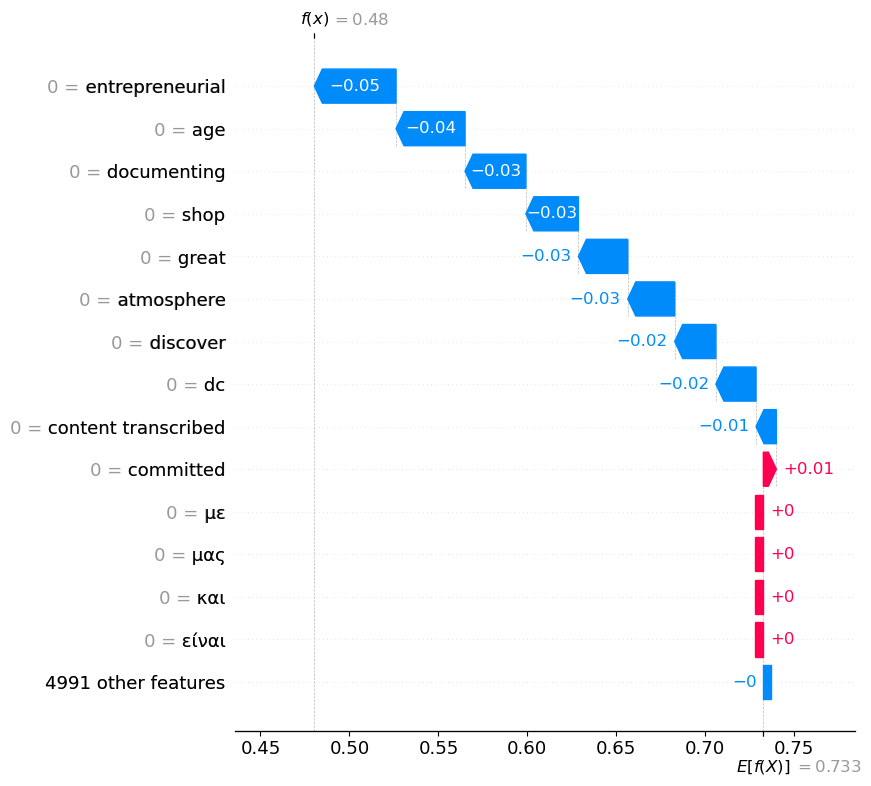

NB score: 0.4105
LSTM score: 0.6866


In [23]:
# === FRAUD example (one posting) ===
fraud_jobs = df[df['fraudulent'] == 1].copy()
fraud_sample = fraud_jobs.sample(1, random_state=42).iloc[0]
fraud_text = fraud_sample["text_all"]

print("="*80)
print("TEST 1: FRAUDULENT JOB")
print("="*80)
print("Title:", safe_display_field(fraud_sample.get("title","")))
print("Location:", safe_display_field(fraud_sample.get("location","")), "\n")

# Ensemble summary (uses your class)
fraud_result = ensemble.predict_with_explanation(fraud_text)
print(f"🔍 FRAUD PROBABILITY: {fraud_result['fraud_probability_pct']}")
print(f"{fraud_result['risk_icon']} RISK LEVEL: {fraud_result['risk_level']}")
print(f"📊 PREDICTED: {fraud_result['ensemble_decision']}")
print(f"✅ CONFIDENCE: {fraud_result['confidence']}\n")

# SHAP detail
print("== SHAP: Naive Bayes (TF-IDF) top contributors ==")
nb_items, nb_exp = shap_explain_nb_for_text(fraud_text, top_k=12, nsamples=150)
for term, val in nb_items:
    arrow = "↑" if val > 0 else "↓"
    print(f"  {arrow} {term:20s} {val:+.4f}")

print("\n== SHAP: LSTM risky tokens (first 20) ==")
tok_vals, lstm_exp = shap_explain_lstm_for_text(fraud_text, max_display=20)
for tok, v in tok_vals[:20]:
    arrow = "↑" if v > 0 else "↓"
    print(f"  {arrow} {tok!r:20s} {v:+.4f}")

# Plots
try:
    shap.plots.waterfall(nb_exp, max_display=15)  # exp is a single instance
except Exception:
    # Some SHAP versions need a 1D Explanation indexed with [0]
    shap.plots.waterfall(nb_exp[0], max_display=15)

shap.plots.text(lstm_exp[0])

print("NB score:", fraud_result['individual_predictions']['naive_bayes_score'])
print("LSTM score:", fraud_result['individual_predictions']['lstm_score'])


In [25]:
#TEST FOR TRULY SYNTHETIC FRAUD JOB - OPTIONAL
synth = """
Work from home, no experience needed. 
We will send you a check, you keep part of the money and send the rest back.
Provide your bank account details and a copy of your ID to get started immediately.
"""

res = ensemble.predict_with_explanation(synth)
print("Ensemble fraud prob:", res['fraud_probability_pct'], "risk:", res['risk_level'])

nb_items_s, _ = shap_explain_nb_for_text(synth, top_k=10, nsamples=150)
print("\nNB top contributors:")
for term, val in nb_items_s:
    arrow = "↑" if val > 0 else "↓"
    print(f"  {arrow} {term:20s} {val:+.4f}")

tok_vals_s, exp_s = shap_explain_lstm_for_text(synth, max_display=20)
print("\nLSTM first 20 tokens:")
for tok, v in tok_vals_s[:20]:
    arrow = "↑" if v > 0 else "↓"
    print(f"  {arrow} {tok!r:20s} {v:+.4f}")

shap.plots.text(exp_s[0])





Ensemble fraud prob: 53.8% risk: MEDIUM RISK


  0%|          | 0/1 [00:00<?, ?it/s]


NB top contributors:
  ↓ cost                 -0.0666
  ↑ work home            +0.0607
  ↑ personally           +0.0527
  ↓ transcribed          -0.0428
  ↑ started              +0.0392
  ↓ reason               -0.0215
  ↑ effort               +0.0213
  ↓ based                -0.0000
  ↓ με                   +0.0000
  ↓ μας                  +0.0000


  0%|          | 0/498 [00:00<?, ?it/s]


LSTM first 20 tokens:
  ↓ '\n'                 +0.0000
  ↓ 'Work '              +0.0000
  ↓ 'from '              +0.0000
  ↓ 'home, '             +0.0000
  ↓ 'no '                +0.0000
  ↓ 'experience '        +0.0000
  ↓ 'needed. \n'         +0.0000
  ↓ 'We '                +0.0000
  ↓ 'will '              +0.0000
  ↓ 'send '              +0.0000
  ↓ 'you '               +0.0000
  ↓ 'a '                 +0.0000
  ↓ 'check, '            +0.0000
  ↓ 'you '               +0.0000
  ↓ 'keep '              +0.0000
  ↓ 'part '              +0.0000
  ↓ 'of '                +0.0000
  ↓ 'the '               +0.0000
  ↓ 'money '             +0.0000
  ↓ 'and '               +0.0000


NB score: 0.4105
LSTM score: 0.6866


In [26]:
#MORE TESTING WUUU -OPTIONAL
synth = """
Work from home, no experience needed. 
We will send you a check, you keep part of the money and send the rest back.
Provide your bank account details and a copy of your ID to get started immediately.
"""

result = ensemble.predict_with_explanation(synth)

print("=== ENSEMBLE SUMMARY ===")
print("Fraud probability:", result["fraud_probability_pct"])
print("Risk level:", result["risk_level"])
print("Decision:", result["ensemble_decision"])
print("Confidence:", result["confidence"])
print("Strategy:", result.get("ensemble_strategy", "N/A"))
print()

print("=== MODEL SCORES ===")
print("Naive Bayes (NB) score:", result["individual_predictions"]["naive_bayes_score"])
print("LSTM score:", result["individual_predictions"]["lstm_score"])
print("Model agreement?:", result["individual_predictions"]["agreement"])

print("\n=== Rule-based boosts (if any) ===")
for d in result.get("boost_details", []):
    print(" -", d)



=== ENSEMBLE SUMMARY ===
Fraud probability: 53.8%
Risk level: MEDIUM RISK
Decision: FRAUD
Confidence: LOW
Strategy: Rule-boosted ensemble (base: 29.8% + boost: 24.0% = 53.8%)

=== MODEL SCORES ===
Naive Bayes (NB) score: 0.6367
LSTM score: 0.1848
Model agreement?: False

=== Rule-based boosts (if any) ===
 - 🚩 No company logo (+5%)
 - 🚩 No screening questions (+5%)
 - 🚩 Urgency language: immediately (+8%)
 - 🚩 Very short description (201 chars) (+6%)


TEST 2: LEGITIMATE JOB
Title: Full Stack Engineer
Location: US, CA, Palo Alto 

🔍 FRAUD PROBABILITY: 10.0%
🟢 RISK LEVEL: LOW RISK
📊 PREDICTED: REAL
✅ CONFIDENCE: HIGH



  0%|          | 0/1 [00:00<?, ?it/s]

== SHAP: NB top negative (legit) contributors ==
  ↓ looking people       -0.0245
  ↓ lift                 -0.0140
  ↓ energy               -0.0120
  ↓ quality product      -0.0113
  ↓ fresh                -0.0048
  ↓ pick                 -0.0047
  ↓ package              -0.0045
  ↓ profitable           -0.0039
  ↓ analysis             -0.0011
  ↓ με                   +0.0000
  ↓ μας                  +0.0000
  ↑ entertainment        +0.0407


  0%|          | 0/498 [00:00<?, ?it/s]


== SHAP: LSTM tokens (first 20) ==
  ↓ 'Full '              -0.0028
  ↓ 'Stack '             -0.0028
  ↓ 'Engineer '          -0.0028
  ↓ 'Declara '           -0.0028
  ↓ 'is '                -0.0026
  ↓ 'focused '           -0.0026
  ↓ 'on '                -0.0026
  ↓ 'bringing '          -0.0026
  ↓ 'data '              -0.0026
  ↓ 'to '                -0.0026
  ↓ 'life. '             -0.0026
  ↓ 'Our '               -0.0026
  ↓ 'technology '        -0.0040
  ↓ 'platform '          -0.0040
  ↓ 'uses '              -0.0019
  ↓ 'machine '           -0.0019
  ↓ 'learning, '         -0.0084
  ↓ 'search, '           -0.0084
  ↓ 'algorithms '        -0.0018
  ↓ 'and '               -0.0000


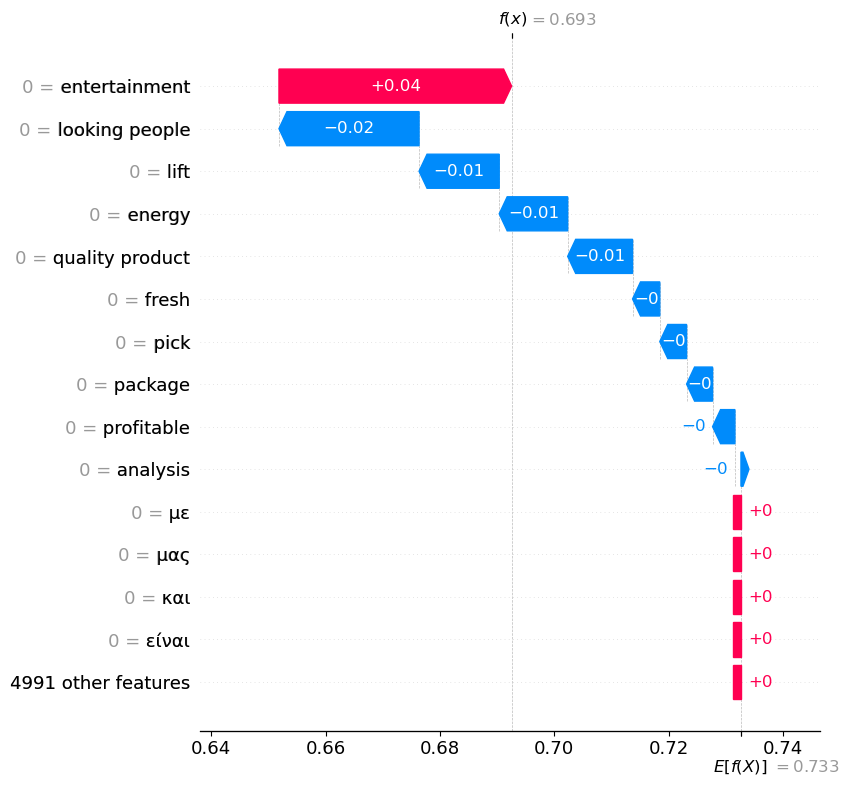

NB score: 0.0000
LSTM score: 0.0005


In [28]:
# === REAL example (one posting) ===
real_jobs = df[df['fraudulent'] == 0].copy()
real_sample = real_jobs.sample(1, random_state=99).iloc[0]
real_text = real_sample["text_all"]

print("="*80)
print("TEST 2: LEGITIMATE JOB")
print("="*80)
print("Title:", safe_display_field(real_sample.get("title","")))
print("Location:", safe_display_field(real_sample.get("location","")), "\n")

real_result = ensemble.predict_with_explanation(real_text)
print(f"🔍 FRAUD PROBABILITY: {real_result['fraud_probability_pct']}")
print(f"{real_result['risk_icon']} RISK LEVEL: {real_result['risk_level']}")
print(f"📊 PREDICTED: {real_result['ensemble_decision']}")
print(f"✅ CONFIDENCE: {real_result['confidence']}\n")

nb_items_r, nb_exp_r = shap_explain_nb_for_text(real_text, top_k=12, nsamples=150)
print("== SHAP: NB top negative (legit) contributors ==")
neg_sorted = sorted(nb_items_r, key=lambda kv: kv[1])[:12]
for term, val in neg_sorted:
    arrow = "↑" if val > 0 else "↓"
    print(f"  {arrow} {term:20s} {val:+.4f}")

tok_vals_r, lstm_exp_r = shap_explain_lstm_for_text(real_text, max_display=20)
print("\n== SHAP: LSTM tokens (first 20) ==")
for tok, v in tok_vals_r[:20]:
    arrow = "↑" if v > 0 else "↓"
    print(f"  {arrow} {tok!r:20s} {v:+.4f}")

try:
    shap.plots.waterfall(nb_exp_r, max_display=15)
except Exception:
    shap.plots.waterfall(nb_exp_r[0], max_display=15)

shap.plots.text(lstm_exp_r[0])

print("NB score:", real_result['individual_predictions']['naive_bayes_score'])
print("LSTM score:", real_result['individual_predictions']['lstm_score'])


Test Job (Synthetic)

In [29]:
# === 10-posting sanity check ===
fraud_samples = fraud_jobs.sample(5, random_state=123).copy()
real_samples  = real_jobs.sample(5, random_state=456).copy()

rows = []
for label, sdf in [("FRAUD", fraud_samples), ("REAL", real_samples)]:
    for _, row in sdf.iterrows():
        text = row["text_all"]
        res = ensemble.predict_with_explanation(text)
        rows.append({
            "True Label": label,
            "Pred": res["ensemble_decision"],
            "Risk": res["risk_level"],
            "NB": res["individual_predictions"]["naive_bayes_score"],
            "LSTM": res["individual_predictions"]["lstm_score"],
            "Correct": (label == res["ensemble_decision"]),
            "Title": safe_display_field(row.get("title",""))
        })

results_df = pd.DataFrame(rows)
display(results_df[["True Label","Pred","Risk","NB","LSTM","Correct","Title"]])
print(f"\nAccuracy on sample: {results_df['Correct'].mean():.2%}")
print(results_df.groupby(["True Label","Risk"])["Correct"].agg(["count","mean"]))


,True Label,Pred,Risk,NB,LSTM,Correct,Title
0,FRAUD,FRAUD,MEDIUM RISK,0.0008,0.4554,True,Structural Engineer
1,FRAUD,FRAUD,HIGH RISK,0.9591,0.9204,True,"URGENT Job Full Time & Part Time, Cash Pay."
2,FRAUD,FRAUD,MEDIUM RISK,0.0155,0.4472,True,CENTER MANAGER
3,FRAUD,FRAUD,HIGH RISK,0.0015,0.7178,True,Java Developer
4,FRAUD,FRAUD,HIGH RISK,0.3188,0.9225,True,Optical Sales
5,REAL,REAL,LOW RISK,0.0017,0.0013,True,Hinckley Apprentice Business Support Coordinat...
6,REAL,REAL,LOW RISK,0.0000,0.0005,True,Operations Manager Cortilia
7,REAL,REAL,LOW RISK,0.1059,0.0050,True,Engineering Drafting Technician/AutoCADD
8,REAL,REAL,MEDIUM RISK,0.0000,0.0004,True,Social Media Designer
9,REAL,REAL,MEDIUM RISK,0.0003,0.0002,True,Sr. Design Engineer Mechanical - 3D CAD



Accuracy on sample: 100.00%
                        count  mean
True Label Risk                    
FRAUD      HIGH RISK        3   1.0
           MEDIUM RISK      2   1.0
REAL       LOW RISK         3   1.0
           MEDIUM RISK      2   1.0


In [30]:
fraud_samples = fraud_jobs.sample(5, random_state=123).copy()
real_samples  = real_jobs.sample(5, random_state=456).copy()

results_list = []
print("\nSampling 10 job postings with rule-boosted ensemble...\n")

for label, sample_df in [("FRAUD", fraud_samples), ("REAL", real_samples)]:
    for _, row in sample_df.iterrows():
        text = combine_text_fields(row)
        result = ensemble.predict_with_explanation(text)
        results_list.append({
            "True Label": label,
            "Predicted": result['ensemble_decision'],
            "Risk": result['risk_level'],
            "NB Score": result['individual_predictions']['naive_bayes_score'],
            "LSTM Score": result['individual_predictions']['lstm_score'],
            "Correct": (label == result['ensemble_decision']),
            "Title": safe_display_field(row.get("title",""))
        })

import pandas as pd
results_df = pd.DataFrame(results_list)
print(results_df[["True Label","Predicted","Risk","NB Score","LSTM Score","Correct","Title"]])

accuracy = results_df['Correct'].mean()
print(f"\n📊 Accuracy on sample: {accuracy:.2%}")
print("Breakdown by risk level:")
print(results_df.groupby(["True Label","Risk"])["Correct"].agg(["count","mean"]))



Sampling 10 job postings with rule-boosted ensemble...

  True Label Predicted         Risk NB Score LSTM Score  Correct  \
0      FRAUD     FRAUD  MEDIUM RISK   0.0008     0.4554     True   
1      FRAUD     FRAUD    HIGH RISK   0.9591     0.9204     True   
2      FRAUD     FRAUD  MEDIUM RISK   0.0155     0.4472     True   
3      FRAUD     FRAUD    HIGH RISK   0.0015     0.7178     True   
4      FRAUD     FRAUD    HIGH RISK   0.3188     0.9225     True   
5       REAL      REAL     LOW RISK   0.0017     0.0013     True   
6       REAL      REAL     LOW RISK   0.0000     0.0005     True   
7       REAL      REAL     LOW RISK   0.1059     0.0050     True   
8       REAL      REAL  MEDIUM RISK   0.0000     0.0004     True   
9       REAL      REAL  MEDIUM RISK   0.0003     0.0002     True   

                                               Title  
0                                Structural Engineer  
1        URGENT Job Full Time & Part Time, Cash Pay.  
2                            